<a href="https://colab.research.google.com/github/mohammed1916/ml/blob/main/Generative_Adversarial_Network_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning with PyTorch : Build a Generative Adversarial Network

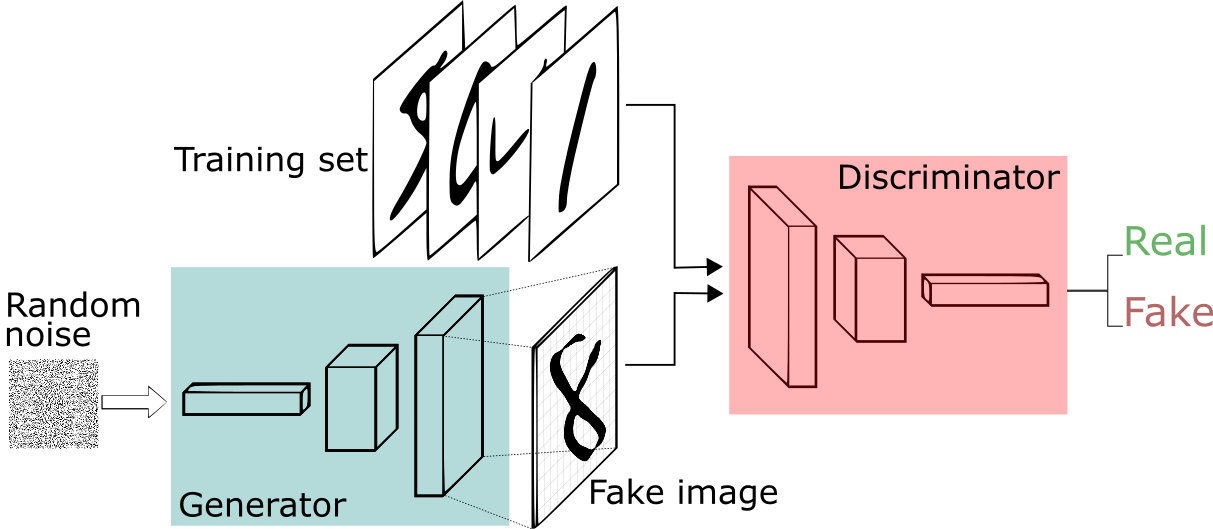

In [1]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Configurations

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lr= 2e-4 # Corrected from 2*10-4
batch_size = 128
noise_dim = 64

beta_1 = 0.5
beta_2 = 0.99

epochs = 20

# Load MNIST Dataset

In [3]:
from torchvision import datasets, transforms as T
train_transform = T.Compose([
    T.RandomRotation((-20, +20)),
    T.ToTensor(),
])

In [4]:
train_set = datasets.MNIST(train=True, download = True, root = 'MNIST', transform = train_transform)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.52MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [5]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

In [6]:
type(train_loader)

torch.utils.data.dataloader.DataLoader

In [7]:
data_iter = iter(train_loader)
images, _ = next(data_iter)
print(images.shape)

torch.Size([128, 1, 28, 28])


# Load Dataset Into Batches

In [8]:
from torchvision.utils import make_grid

In [9]:
# 'show_tensor_images' : function is used to plot some of images from the batch

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.axis('off')
    plt.show()

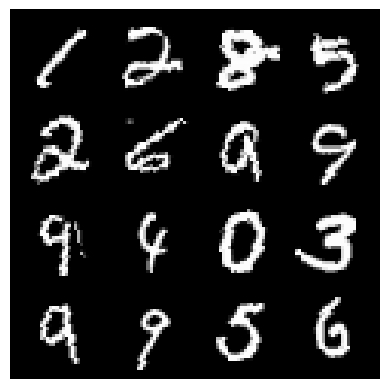

In [10]:
show_tensor_images(images, num_images=16)

# Create Discriminator Network

In [11]:
#In case if torch summary is not installed

!pip install torchsummary

In [12]:
def get_discriminator_block(in_channels, out_channels, kernel_size, stride):
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride),
        torch.nn.BatchNorm2d(out_channels),
        torch.nn.LeakyReLU(0.2)
    )

In [13]:
'''

Network : Discriminator

input : (bs, 1, 28, 28)
      |                                                                                               ---- SUMMARY ----
      V
Conv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)
BatchNorm2d()                                                                                          #(bs, 16, 13, 13)
LeakyReLU()                                                                                            #(bs, 16, 13, 13)
      |
      V
Conv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)
BatchNorm2d()                                                                                          #(bs, 32, 5, 5)
LeakyReLU()                                                                                            #(bs, 32, 5, 5)
      |
      V
Conv2d( in_channels = 32, out_channels = 64, kernel_size = (5,5), stride = 2)                          #(bs, 64, 1, 1)
BatchNorm2d()                                                                                          #(bs, 64, 1, 1)
LeakyReLU()                                                                                            #(bs, 64, 1, 1)
      |
      V
Flatten()                                                                                              #(bs, 64)
Linear(in_features = 64, out_features = 1)                                                             #(bs, 1)

'''

'\n\nNetwork : Discriminator\n\ninput : (bs, 1, 28, 28)\n      |                                                                                               ---- SUMMARY ----\n      V\nConv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)\nBatchNorm2d()                                                                                          #(bs, 16, 13, 13)\nLeakyReLU()                                                                                            #(bs, 16, 13, 13)\n      |\n      V\nConv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)\nBatchNorm2d()                                                                                          #(bs, 32, 5, 5)\nLeakyReLU()                                                                                            #(bs, 32, 5, 5)\n      |\n      V\nConv2d( in_channels = 32, out_channels = 64, kernel

In [14]:
class Discriminator(torch.nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.block1 = get_discriminator_block(1, 16, 3, 2)
    self.block2 = get_discriminator_block(16, 32, 5, 2)
    self.block3 = get_discriminator_block(32, 64, 5, 2)

    self.flatten = torch.nn.Flatten()
    self.linear = torch.nn.Linear(64, 1)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.flatten(x)
    x = self.linear(x)
    return x

In [15]:
D = Discriminator()
D.to(device)

Discriminator(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [16]:
from torchsummary import summary
summary(D, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 13, 13]             160
       BatchNorm2d-2           [-1, 16, 13, 13]              32
         LeakyReLU-3           [-1, 16, 13, 13]               0
            Conv2d-4             [-1, 32, 5, 5]          12,832
       BatchNorm2d-5             [-1, 32, 5, 5]              64
         LeakyReLU-6             [-1, 32, 5, 5]               0
            Conv2d-7             [-1, 64, 1, 1]          51,264
       BatchNorm2d-8             [-1, 64, 1, 1]             128
         LeakyReLU-9             [-1, 64, 1, 1]               0
          Flatten-10                   [-1, 64]               0
           Linear-11                    [-1, 1]              65
Total params: 64,545
Trainable params: 64,545
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

# Create Generator Network

In [17]:
'''

Network : Generator

z_dim = 64
input : (bs,z_dim)

      |
      | Reshape
      V

input : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)
      |                                                                                               ---- SUMMARY ----
      V
ConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)
BatchNorm2d()                                                                                          #(bs, 256, 3, 3)
ReLU()                                                                                                 #(bs, 256, 3, 3)
      |
      V
ConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)
BatchNorm2d()                                                                                          #(bs, 128, 6, 6)
ReLU()                                                                                                 #(bs, 128, 6, 6)
      |
      V
ConvTranspose2d( in_channels = 128, out_channels = 64, kernel_size = (3,3), stride = 2)                #(bs, 64, 13, 13)
BatchNorm2d()                                                                                          #(bs, 64, 13, 13)
ReLU()                                                                                                 #(bs, 64, 13, 13)
      |
      V
ConvTranspose2d( in_channels = 64, out_channels = 1, kernel_size = (4,4), stride = 2)                  #(bs, 1, 28, 28)
Tanh()                                                                                                 #(bs, 1, 28, 28)

'''

'\n\nNetwork : Generator\n\nz_dim = 64\ninput : (bs,z_dim)\n\n      |\n      | Reshape\n      V\n\ninput : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)\n      |                                                                                               ---- SUMMARY ----\n      V\nConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)\nBatchNorm2d()                                                                                          #(bs, 256, 3, 3)\nReLU()                                                                                                 #(bs, 256, 3, 3)\n      |\n      V\nConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)\nBatchNorm2d()                                                                                          #(bs, 128, 6, 6)\nReLU()                                                                                 

In [18]:
def get_generator_block(in_channels, out_channels, kernel_size, stride, final_block=False):
  if final_block == True:
    return torch.nn.Sequential(
        torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
        torch.nn.Tanh()
    )
  return torch.nn.Sequential(
      torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
      torch.nn.BatchNorm2d(out_channels),
      torch.nn.ReLU()
  )

In [19]:
class Generator(torch.nn.Module):
  def __init__(self, z_dim):
    super(Generator, self).__init__()
    self.noise_dim = z_dim
    self.block1 = get_generator_block(z_dim, 256, (3,3),2)
    self.block2 = get_generator_block(256, 128, (4,4),1)
    self.block3 = get_generator_block(128, 64, (3,3), 2)

    self.block4 = get_generator_block(64, 1, (4,4), 2, final_block=True)
  def forward(self, x):
    x = x.view(-1, self.noise_dim, 1, 1)
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    return x


In [20]:
G = Generator(noise_dim)
G.to(device)
summary(G, input_size=(1,noise_dim))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 256, 3, 3]         147,712
       BatchNorm2d-2            [-1, 256, 3, 3]             512
              ReLU-3            [-1, 256, 3, 3]               0
   ConvTranspose2d-4            [-1, 128, 6, 6]         524,416
       BatchNorm2d-5            [-1, 128, 6, 6]             256
              ReLU-6            [-1, 128, 6, 6]               0
   ConvTranspose2d-7           [-1, 64, 13, 13]          73,792
       BatchNorm2d-8           [-1, 64, 13, 13]             128
              ReLU-9           [-1, 64, 13, 13]               0
  ConvTranspose2d-10            [-1, 1, 28, 28]           1,025
             Tanh-11            [-1, 1, 28, 28]               0
Total params: 747,841
Trainable params: 747,841
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [21]:
# Replace Random initialized weights to Normal weights
from torch import nn
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [22]:
D = D.apply(weights_init)
G = G.apply(weights_init)

# Create Loss Function and Load Optimizer

In [23]:
def real_loss(discriminator_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(discriminator_pred)
  loss = criterion(discriminator_pred, ground_truth)
  return loss

def fake_loss(discriminator_pred):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(discriminator_pred)
  loss = criterion(discriminator_pred, ground_truth)
  return loss

In [24]:
D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta_1, beta_2))
G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta_1, beta_2))

# Training Loop

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 1/20
Discriminator Loss : 0.6859340205121396
Generator Loss : 0.7105396180264731


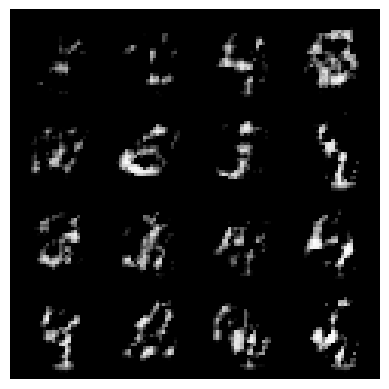

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 2/20
Discriminator Loss : 0.6738611744410956
Generator Loss : 0.7131583358941556


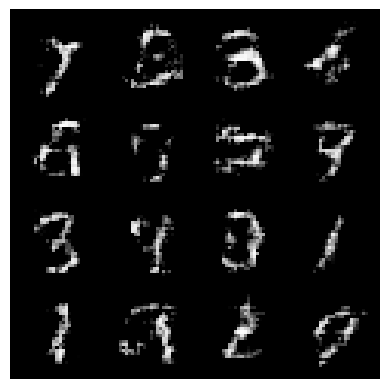

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 3/20
Discriminator Loss : 0.6249923553548133
Generator Loss : 0.7711372746587563


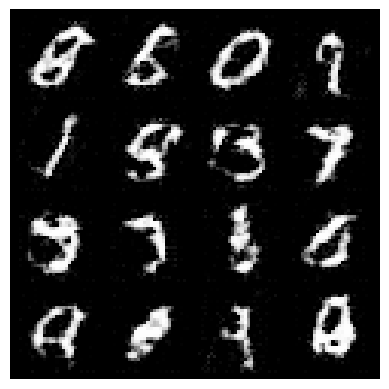

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 4/20
Discriminator Loss : 0.5902744224076586
Generator Loss : 0.8196471854567782


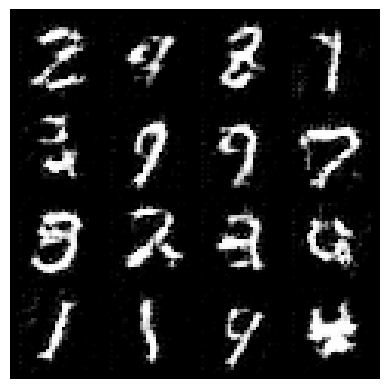

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 5/20
Discriminator Loss : 0.568869138196079
Generator Loss : 0.8640393705002026


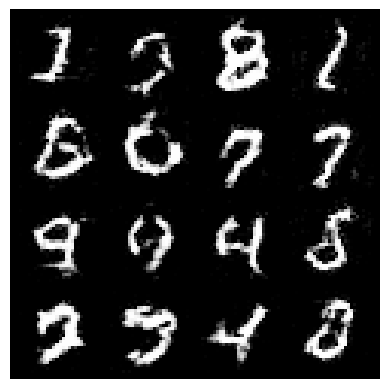

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 6/20
Discriminator Loss : 0.5664434664285005
Generator Loss : 0.8881036129587495


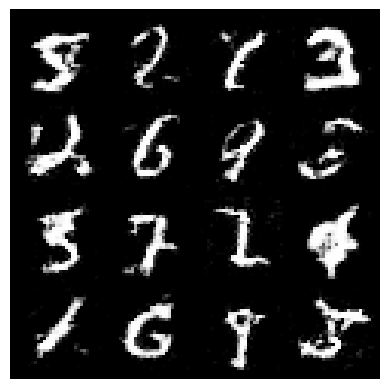

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 7/20
Discriminator Loss : 0.5680838595829538
Generator Loss : 0.9032045437583028


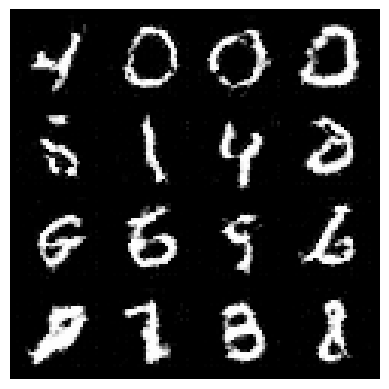

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 8/20
Discriminator Loss : 0.5762469045388927
Generator Loss : 0.9060122867637097


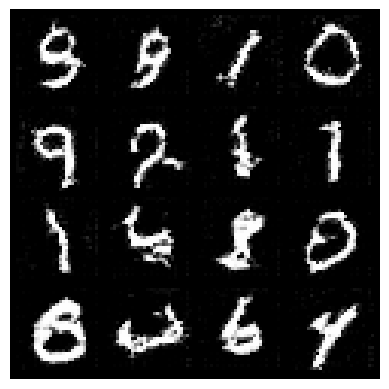

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 9/20
Discriminator Loss : 0.5864203268531035
Generator Loss : 0.9025227735037489


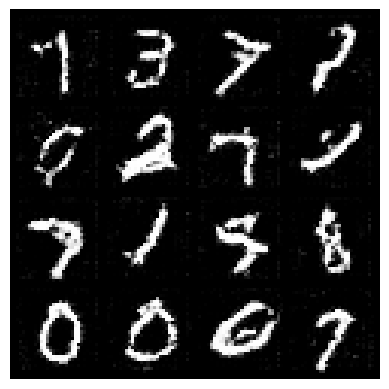

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 10/20
Discriminator Loss : 0.5966979975639376
Generator Loss : 0.8951231194203342


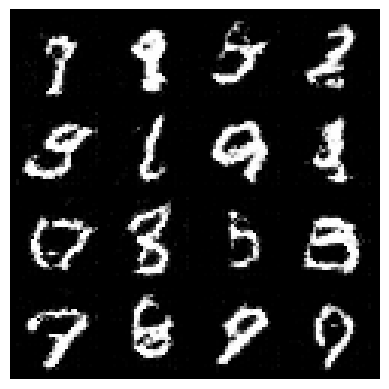

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 11/20
Discriminator Loss : 0.6069490802821829
Generator Loss : 0.8839537167091613


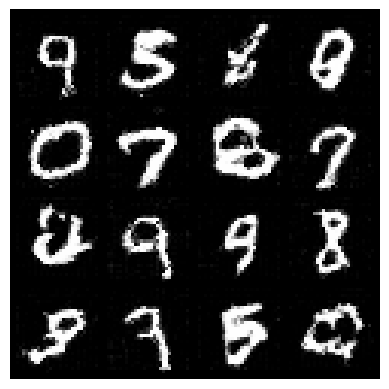

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 12/20
Discriminator Loss : 0.6134724067980801
Generator Loss : 0.8736120740742063


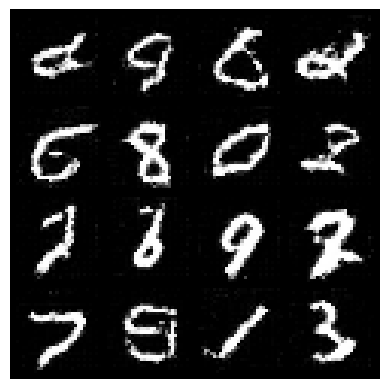

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 13/20
Discriminator Loss : 0.6180552044656994
Generator Loss : 0.8698526004484213


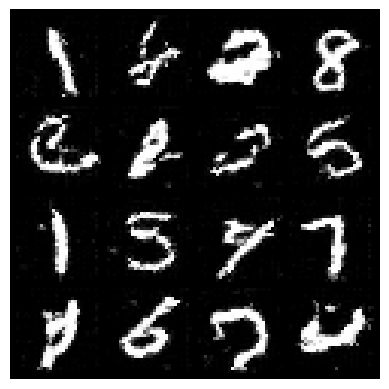

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 14/20
Discriminator Loss : 0.6220102025501764
Generator Loss : 0.862670057236767


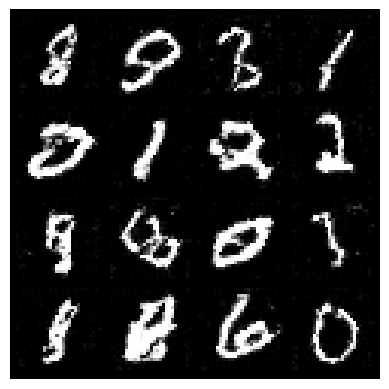

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 15/20
Discriminator Loss : 0.6228764137225364
Generator Loss : 0.8623452476346924


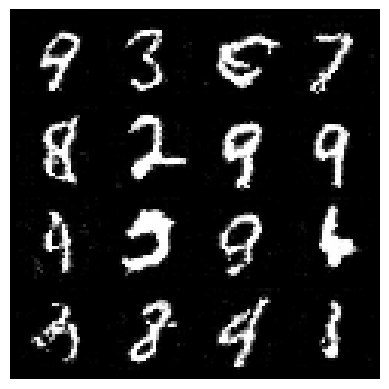

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 16/20
Discriminator Loss : 0.6259647037174656
Generator Loss : 0.8546191629316253


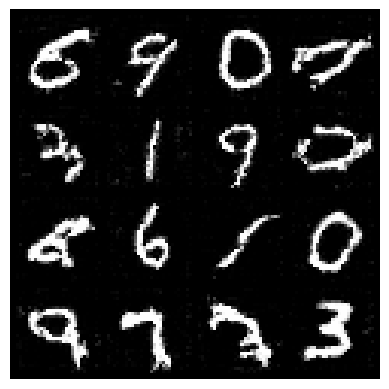

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 17/20
Discriminator Loss : 0.6269832473319731
Generator Loss : 0.8563612286470084


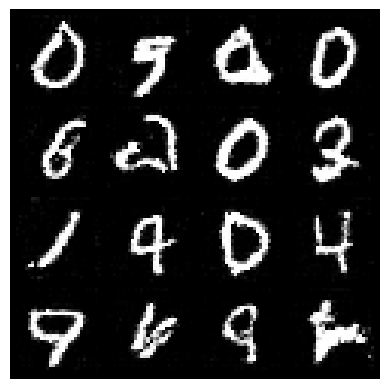

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 18/20
Discriminator Loss : 0.6275915621694471
Generator Loss : 0.8540871402602206


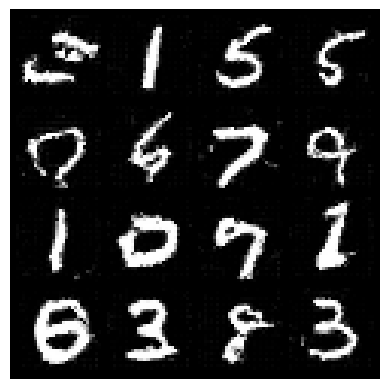

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 19/20
Discriminator Loss : 0.6294628736306863
Generator Loss : 0.855145141132859


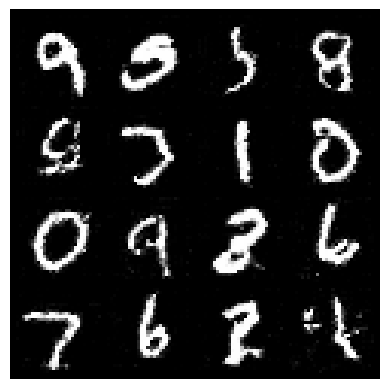

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch : 20/20
Discriminator Loss : 0.6293479967981513
Generator Loss : 0.8514959181803884


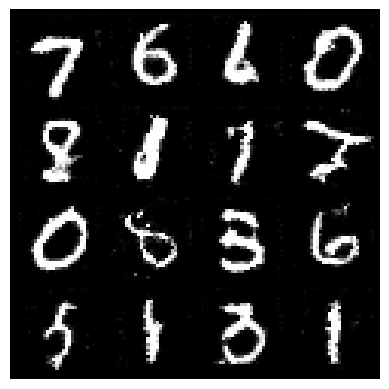

In [25]:
for i in range(epochs):
  total_d_loss = 0.0
  total_g_loss = 0.0

  for real_img, _ in tqdm(train_loader):
    real_img = real_img.to(device)

    noise = torch.randn(batch_size, noise_dim, device=device)
    D_opt.zero_grad()

    fake_img = G(noise)
    real_pred = D(real_img)
    fake_pred = D(fake_img)

    d_real_loss = real_loss(real_pred)
    d_fake_loss = fake_loss(fake_pred)
    d_loss = (d_real_loss + d_fake_loss) /2
    total_d_loss += d_loss.item()

    d_loss.backward()
    D_opt.step()

    G_opt.zero_grad()
    noise = torch.randn(batch_size, noise_dim, device=device)
    fake_img = G(noise)
    fake_pred = D(fake_img)
    g_loss = real_loss(fake_pred)

    total_g_loss += g_loss.item()
    g_loss.backward()
    G_opt.step()

  print(f'Epoch : {i+1}/{epochs}')
  print(f'Discriminator Loss : {total_d_loss/len(train_loader)}')
  print(f'Generator Loss : {total_g_loss/len(train_loader)}')
  avg_d_loss = total_d_loss/len(train_loader)
  avg_g_loss = total_g_loss/len(train_loader)
  show_tensor_images(fake_img)

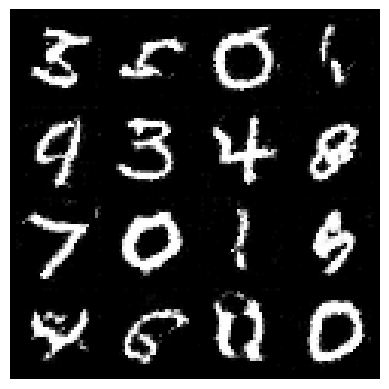

In [26]:
# Run after training is completed.
# Now you can use Generator Network to generate handwritten images

noise = torch.randn(batch_size, noise_dim, device = device)
generated_image = G(noise)

show_tensor_images(generated_image)